# SmartDs Spherical Shell Mass Flux (Starter)

This notebook loads the 3D BATSRUS sample file, samples a spherical shell at `R=10`, computes the radial mass flux on that shell, and plots it as a 2D map.

It reuses the **library** for shell sampling and mass-loss integration (no VTK/PyVista, no custom resampling).

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt

from starwinds_analysis.smart_ds import SmartDs
from starwinds_analysis.data.samples import get_sample
from starwinds_analysis.physics.mass_loss import (
    mass_loss_vs_radius,
    sample_shell_mass_flux_map,
)
from starwinds_analysis.physics.plotting import plot_shell_mass_flux_lonlat

plt.rcParams['figure.dpi'] = 120


## Load the 3D Sample File

Defaults to `sample_data/3d__var_3_n00060000.plt`.

In [ ]:
DATA_FILE = get_sample('3d__var_1_n00060000.plt')
STAR_RADIUS_M = 696_000_000.0  # feed into griblet/BATSRUS graph near the top
sds = SmartDs.from_file(DATA_FILE)
sds.add_batsrus_graph(body_radius_m=STAR_RADIUS_M)
# DONE how many times do i need to say to remove this? just put print(sds).
print(sds)


Using: /Users/dagfev/Documents/starwinds/starwinds-analysis/sample_data/3d__var_1_n00060000.plt
Title: BATSRUS: 3D Data, 2011/02/16 17:26:00.000
Zone : 3D   N=0060000
Points: 794624
Variables: 24
Graph-fed stellar radius [m]: 6.960000e+08


## Sample a Spherical Shell at `R = 10` and Compute Mass Flux

The shell sampling uses the library grid sampler (for plotting on a regular `theta/phi` grid).

In [ ]:
R_SHELL = 10.0  # in BATSRUS coordinate units (typically body radii)
N_POLAR = 48
N_AZIMUTH = 2 * N_POLAR

shell_mass_flux = sample_shell_mass_flux_map(
    sds,
    R_SHELL,
    body_radius_m=STAR_RADIUS_M,
    n_polar=N_POLAR,
    n_azimuth=N_AZIMUTH,
    method='nearest',
)

print('Shell grid shape (theta, phi):', shell_mass_flux.mass_flux_kg_m2_s.shape)
shell_mass_flux.summary()


Shell grid shape (theta, phi): (48, 96)


{'finite_cells': 4608,
 'total_cells': 4608,
 'nonpositive_cells': 0,
 'min [kg/m^2/s]': 7.913949188187682e-13,
 'max [kg/m^2/s]': 3.5410737508222823e-12}

In [ ]:
# The map is already in SI units (kg/m^2/s) and on a native lon/lat shell grid.
# The plotting helper handles linear/log rendering and the under-color for inflow.
# DONE for scripts that take time, we should generate the data in a different cell than in the plotting cell.
# Cell 5 computes the shell data; the plotting happens below.


In [ ]:
# DONE have a linear scale option easily avaiable.
MASS_FLUX_SCALE = 'log'  # change to 'linear' for a linear color scale


Under-color cells shown: 0


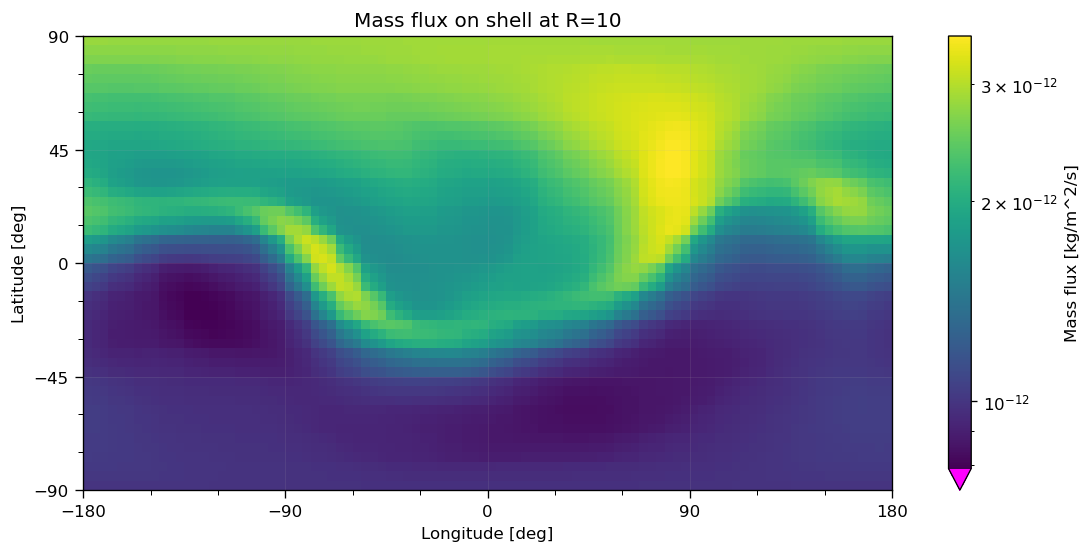

In [ ]:
# 2D shell plot in longitude/latitude using the native theta/phi sampling grid
# We assume the wind mass flux is mostly outward (>0). Non-positive values are shown with the colormap under-color.
# DONE the percentiles scaling is too fancy. We can just use the min/max of the positive values.
fig, ax, extra = plot_shell_mass_flux_lonlat(shell_mass_flux, scale=MASS_FLUX_SCALE)
if 'n_nonpositive' in extra:
    print(f"Under-color cells shown: {extra['n_nonpositive']}")
plt.show()


## Mass-Loss Rate at `R = 10` (Library Function)

This uses `mass_loss_vs_radius(...)` with **Fibonacci-sphere sampling** for the shell integral.
For notebook responsiveness we use a lower integration resolution than the plotting shell.
(The runtime scales with the number of shell sample points.)

In [ ]:
# Optional cross-check: integrate the plotted grid-shell mass flux directly
mass_loss_grid, coverage_grid = shell_mass_flux.integrate()

# Use a smaller Fibonacci shell for the integral so this cell stays responsive.
# Effective Fibonacci sample count is N_MASS_LOSS_POLAR * N_MASS_LOSS_AZIMUTH.
N_MASS_LOSS_POLAR = 16
N_MASS_LOSS_AZIMUTH = 32
print(f"Fibonacci integration points: {N_MASS_LOSS_POLAR * N_MASS_LOSS_AZIMUTH}")

# Why do you have this dumbass function? What do you think the notebooks are for?
profile = mass_loss_vs_radius(
    sds,
    [R_SHELL],
    body_radius_m=STAR_RADIUS_M,
    n_polar=N_MASS_LOSS_POLAR,
    n_azimuth=N_MASS_LOSS_AZIMUTH,
    sampling='fibonacci',
    method='nearest',
)

dotm_lib = float(profile['mass_loss [kg/s]'][0])
cov_lib = float(profile['coverage [none]'][0])

print(f"Grid-shell integral (same plotted shell): {mass_loss_grid:.6e} kg/s")
print(f"Grid-shell coverage             : {coverage_grid:.6f}")
print(f"Library mass_loss_vs_radius     : {dotm_lib:.6e} kg/s")
print(f"Library coverage                : {cov_lib:.6f}")


Fibonacci integration points: 512
Grid-shell integral (same plotted shell): 1.042047e+09 kg/s
Grid-shell coverage             : 1.000000
Library mass_loss_vs_radius     : 1.040809e+09 kg/s
Library coverage                : 1.000000
